# 03f — Independent MapBiomas labels: four experiments (Colombia)

Labels come from `02d_mapbiomas_labels`: the MapBiomas Colombia C3
vegetation-loss / secondary-vegetation rule, plus our regrowth window. Every
model uses the step-2 specification (`make_rf`: 500 trees, `max_features=3`,
bootstrap, seed 20261003, 39,523 balanced training records), the same domain,
and the same exact WGS84 areas (1-in-100 grid, pixel area × 100).

MapBiomas-labelled points are the grid points of `02b` (a systematic,
self-weighting sample of the study domain). They are split pixel-wise into a
training pool (6/10.87) and a validation part (4.87/10.87), as in step 2.
Balanced validation = all class-1 validation points plus as many random class-0
points. "Natural prevalence" metrics use all validation points, weighted by
area.

- **E1 — labels over the same period.** MapBiomas regrowth 2000→2012 that
  persists as forest to 2016, compared with Fagan. Prevalence. The step-2 model
  retrained on MapBiomas labels: accuracy (random, HEALPix-blocked), expected
  area (uncalibrated and prior-shift with the MapBiomas prevalence), agreement
  with the authors' map.
- **E2 — forward test.** Train on 2000→2012 regrowth with 2000 predictors;
  predict 2012→2024 regrowth with the predictors updated to 2012; evaluate on
  the 2012–2024 outcomes. Calibration uses only the period-1 prevalence.
- **E3 — pre-2000 history (extension).** E1 plus two MapBiomas 1985–1999
  history predictors.
- **E4 — cross-scoring.** The Fagan-trained step-2 model on MapBiomas labels;
  the MapBiomas model on Fagan labels; the authors' map on MapBiomas
  non-regrowth and regrowth points.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from healpix_geo.nested import lonlat_to_healpix, vertices
from matplotlib.collections import PolyCollection
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedKFold

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
SMOKE = os.environ.get("SMOKE", "0") == "1"
CLEAN = Path("../data/clean_smoke" if SMOKE else "../data/clean")
RESULTS = Path("../results/smoke" if SMOKE else "../results")
FIGURES = Path("../figures/smoke" if SMOKE else "../figures")
for d in (RESULTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)
N_TREES = 100 if SMOKE else 500
SEED = 20261003
MHA = 1e10
GRID_W = 100
FINAL_VARS = ["forest_density_2000", "dist_forest_2000", "ocdens", "phihox", "pc1", "pc2", "pc3", "pc4", "lc_2000", "biome"]
PRED_MAP = {"forest_density_2000": "forest_density_2018", "dist_forest_2000": "dist_forest_2018", "lc_2000": "lc_2015"}
VARS_2018 = [PRED_MAP.get(v, v) for v in FINAL_VARS]
VARS_FW = [v.replace("2000", "2012") for v in FINAL_VARS]
HIST_VARS = ["mb_years_since_forest", "mb_years_anthropic_8599"]
COL_SHARE = 188_921 / 4_780_000
N_TRAIN = 2_000 if SMOKE else int(round(1_000_000 * COL_SHARE))
N_CV_POOL = 6_000 if SMOKE else 151_980  # balanced CV pool, same size as the step-2 training pool
POOL_SHARE = 6 / 10.87
HP_DEPTH = 8

grid = pd.read_parquet(CLEAN / "pred_grid.parquet")
mbg = pd.read_parquet(CLEAN / "mapbiomas_grid.parquet")
assert (grid.grow.to_numpy() == mbg.grow.to_numpy()).all() and (grid.gcol.to_numpy() == mbg.gcol.to_numpy()).all()
grid = pd.concat([grid, mbg.drop(columns=["grow", "gcol"])], axis=1)
del mbg
samples = pd.read_parquet(CLEAN / "samples.parquet")
mbs = pd.read_parquet(CLEAN / "mapbiomas_samples.parquet")
assert (samples.grow.to_numpy() == mbs.grow.to_numpy()).all()
samples = pd.concat([samples, mbs.drop(columns=["grow", "gcol", "set", "label"])], axis=1)
del mbs
sums = pd.read_csv(CLEAN / "tile_sums.csv").drop(columns="tile").sum()
PI_FAGAN = float(sums["class1_area_ell"] / (sums["class1_area_ell"] + sums["class0_area_ell"]))
grid["a"] = grid.area_ell * GRID_W
rng = np.random.default_rng(SEED)
grid["mb_set"] = np.where(rng.random(len(grid)) < POOL_SHARE, "train_pool", "validation")
print(f"grid {len(grid):,}; samples {len(samples):,}; Fagan prevalence {PI_FAGAN:.5f}")


def make_rf(max_features: int = 3, seed: int = SEED) -> RandomForestClassifier:
    """Identical to 03_analysis.make_rf (R randomForest classification defaults)."""
    return RandomForestClassifier(n_estimators=N_TREES, max_features=max_features, min_samples_leaf=1, bootstrap=True,
                                  oob_score=True, n_jobs=-1, random_state=seed)


def balanced(df: pd.DataFrame, label: str, n: int, seed: int = SEED) -> pd.DataFrame:
    return pd.concat([g.sample(n=min(n // 2, len(g)), random_state=seed) for _, g in df.groupby(label)])


def balanced_val(df: pd.DataFrame, label: str, seed: int = SEED) -> pd.DataFrame:
    n1 = int((df[label] == 1).sum())
    return pd.concat([df[df[label] == 1], df[df[label] == 0].sample(n=min(n1, int((df[label] == 0).sum())),
                                                                       random_state=seed)])


def prior_shift(p: np.ndarray, pi: float, train_prev: float = 0.5) -> np.ndarray:
    num = p * pi / train_prev
    return num / (num + (1 - p) * (1 - pi) / (1 - train_prev))


def scores(y: np.ndarray, p: np.ndarray) -> dict[str, float]:
    return {"accuracy": float(((p > 0.5) == y).mean()), "balanced_accuracy": float(balanced_accuracy_score(y, p > 0.5)),
            "auc": float(roc_auc_score(y, p)) if len(np.unique(y)) == 2 else np.nan,
            "recall_regrowth": float((p[y == 1] > 0.5).mean()), "share_gt05_nonregrowth": float((p[y == 0] > 0.5).mean()),
            "mean_p_nonregrowth": float(p[y == 0].mean()), "n": int(len(y)), "n_regrowth": int((y == 1).sum())}


def complete(df: pd.DataFrame, vars_: list[str]) -> pd.DataFrame:
    return df.dropna(subset=vars_)


def cv_rows(pool: pd.DataFrame, label: str, vars_: list[str], tag: str) -> list[dict]:
    pv = balanced(pool, label, N_CV_POOL, SEED + 7).reset_index(drop=True)
    X, y = pv[vars_].to_numpy(), pv[label].to_numpy()
    schemes = {"random": StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y)}
    for depth in (6, 7):
        cells = lonlat_to_healpix(pv.lon.to_numpy(), pv.lat.to_numpy(), depth, ellipsoid="WGS84")
        schemes[f"healpix_d{depth}"] = GroupKFold(min(5, len(np.unique(cells)))).split(X, y, groups=cells)
    out = []
    mf = max(1, int(np.floor(np.sqrt(len(vars_)))))
    for name, splits in schemes.items():
        accs, baccs = [], []
        for k, (tri, tei) in enumerate(splits):
            sub = np.random.default_rng(SEED + k).choice(tri, min(N_TRAIN, len(tri)), replace=False)
            p = make_rf(mf).fit(X[sub], y[sub]).predict_proba(X[tei])[:, 1]
            accs.append(float(((p > 0.5) == y[tei]).mean()))
            baccs.append(float(balanced_accuracy_score(y[tei], p > 0.5)))
        out.append(dict(experiment=tag, metric=f"cv_{name}_accuracy", value=np.mean(accs), sd=np.std(accs, ddof=1),
                        n=len(pv), note=" ".join(f"{a:.4f}" for a in accs)))
        out.append(dict(experiment=tag, metric=f"cv_{name}_balanced_accuracy", value=np.mean(baccs),
                        sd=np.std(baccs, ddof=1), n=len(pv), note=""))
        print(out[-2])
    return out

grid 12,161,726; samples 275,336; Fagan prevalence 0.01644


## E1 — MapBiomas vs Fagan labels, 2000→2012 regrowth persisting to 2016

In [3]:
L = "mb_label_e1"
lab_grid = grid[grid[L] >= 0]
PI_MB = float(lab_grid.a[lab_grid[L] == 1].sum() / lab_grid.a.sum())
e1_lab = []


def lab_row(metric: str, value: float, n: int | None = None, note: str = "") -> None:
    e1_lab.append(dict(metric=metric, value=value, n=n, note=note))


lab_row("prevalence_mapbiomas", PI_MB, len(lab_grid), "MB class-1 area / (class-0 + class-1) area, grid, exact WGS84 areas")
lab_row("prevalence_fagan", PI_FAGAN, None, "Fagan regrowth / sampling domain, exact 30 m sums (02b)")
lab_row("mb_regrowth_area_mha", float(lab_grid.a[lab_grid[L] == 1].sum() / MHA), int((lab_grid[L] == 1).sum()))
lab_row("mb_labelled_area_mha", float(lab_grid.a.sum() / MHA), len(lab_grid))
lab_row("fagan_regrowth_area_exact_mha", float(sums["class1_area_ell"] / MHA))
lab_row("fagan_class0_area_exact_mha", float(sums["class0_area_ell"] / MHA))
lab_row("domain_area_exact_mha", float(sums["domain_area_ell"] / MHA))
fa = grid[grid.label >= 0]
for fl, name in [(1, "fagan_regrowth"), (0, "fagan_class0")]:
    sub = fa[fa.label == fl]
    for ml, mname in [(1, "mb_regrowth"), (0, "mb_nonregrowth"), (-1, "mb_excluded")]:
        lab_row(f"grid_{name}_area_share_{mname}", float(sub.a[sub[L] == ml].sum() / sub.a.sum()), len(sub),
                "area-weighted, grid points of the 02b class masks")
    lab_row(f"grid_{name}_area_share_mb_any_regen_2001_2012", float(sub.a[sub.mb_regen_any_2001_2012].sum() / sub.a.sum()),
            len(sub), "any MapBiomas regeneration event (to forest or non-forest natural)")
    lab_row(f"grid_{name}_area_share_mb_forest_2000", float(sub.a[np.isin(sub.mb_code_2000, [1, 3, 5, 6, 49])].sum()
                                                            / sub.a.sum()), len(sub))
mb_in_f0 = float(fa.a[(fa.label == 0) & (fa[L] == 1)].sum())
lab_row("mb_regrowth_area_inside_fagan_class0_mha", mb_in_f0 / MHA, None,
        "regrowth by MapBiomas inside the domain that step 2 treats as class 0 (label omission)")
lab_row("share_of_mb_regrowth_area_in_fagan_class0", mb_in_f0 / float(grid.a[grid[L] == 1].sum()))
lab_row("share_of_mb_regrowth_area_in_fagan_regrowth", float(fa.a[(fa.label == 1) & (fa[L] == 1)].sum()
                                                             / grid.a[grid[L] == 1].sum()))
for st in ["validation", "all"]:
    s = samples if st == "all" else samples[samples.set == "validation"]
    for fl, name in [(1, "fagan_regrowth"), (0, "fagan_class0")]:
        sub = s[s.label == fl]
        for ml, mname in [(1, "mb_regrowth"), (0, "mb_nonregrowth"), (-1, "mb_excluded")]:
            lab_row(f"points_{st}_{name}_share_{mname}", float((sub[L] == ml).mean()), len(sub),
                    f"step-2 sample points ({st})")
        lab_row(f"points_{st}_{name}_share_mb_any_regen_2001_2012", float(sub.mb_regen_any_2001_2012.mean()), len(sub))
        lab_row(f"points_{st}_{name}_share_mb_regrowth_among_mb_labelled",
                float((sub[L] == 1).sum() / max(1, (sub[L] >= 0).sum())), int((sub[L] >= 0).sum()))
e1_labels = pd.DataFrame(e1_lab)
e1_labels.to_csv(RESULTS / "mapbiomas_e1_labels.csv", index=False)
with pd.option_context("display.width", 200, "display.max_colwidth", 70, "display.max_rows", 100):
    print(e1_labels.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                                                              metric   value            n                                                                                   note
                                                prevalence_mapbiomas  0.0546 2982114.0000                    MB class-1 area / (class-0 + class-1) area, grid, exact WGS84 areas
                                                    prevalence_fagan  0.0164          NaN                                Fagan regrowth / sampling domain, exact 30 m sums (02b)
                                                mb_regrowth_area_mha  1.2461  162869.0000                                                                                       
                                                mb_labelled_area_mha 22.8111 2982114.0000                                                                                       
                                       fagan_regrowth_area_exact_mha  0.2517          NaN                          

### E1 model: the step-2 specification retrained on MapBiomas labels

In [4]:
lab_c = complete(lab_grid, FINAL_VARS)
pool_mb = lab_c[lab_c.mb_set == "train_pool"]
val_mb = lab_c[lab_c.mb_set == "validation"]
val_mb_bal = balanced_val(val_mb, L)
train_mb = balanced(pool_mb, L, N_TRAIN)
rf_mb = make_rf().fit(train_mb[FINAL_VARS].to_numpy(), train_mb[L].to_numpy())
rf_fagan_train = balanced(samples[samples.set == "train_pool"], "label", N_TRAIN)  # exact step-2 draw of 03
rf_fagan = make_rf().fit(rf_fagan_train[FINAL_VARS].to_numpy(), rf_fagan_train.label.to_numpy())
fag_val = samples[samples.set == "validation"]
print("Fagan model refit, validation accuracy (03: 0.8867):",
      round(float(((rf_fagan.predict_proba(fag_val[FINAL_VARS].to_numpy())[:, 1] > 0.5) == fag_val.label).mean()), 4))

e1 = []


def add(exp: str, metric: str, value: float, n: int | None = None, note: str = "", sd: float | None = None) -> None:
    e1.append(dict(experiment=exp, metric=metric, value=value, sd=sd, n=n, note=note))


p_val_mb = rf_mb.predict_proba(val_mb_bal[FINAL_VARS].to_numpy())[:, 1]
for k, v in scores(val_mb_bal[L].to_numpy(), p_val_mb).items():
    add("E1_mapbiomas_model", f"validation_balanced_{k}", v, len(val_mb_bal), "MB labels, balanced validation, 2000 inputs")
add("E1_mapbiomas_model", "oob_accuracy", float(rf_mb.oob_score_), len(train_mb))
p_val_all = rf_mb.predict_proba(val_mb[FINAL_VARS].to_numpy())[:, 1]
yv, wv = val_mb[L].to_numpy(), val_mb.a.to_numpy()
for nm, s in [("uncalibrated", p_val_all), ("prior_shift", prior_shift(p_val_all, PI_MB))]:
    add("E1_mapbiomas_model", f"brier_natural_prevalence_{nm}", float(brier_score_loss(yv, s, sample_weight=wv)), len(yv),
        "all MB-labelled validation points, area-weighted")
add("E1_mapbiomas_model", "prevalence_mapbiomas", PI_MB)
e1 += cv_rows(pool_mb, L, FINAL_VARS, "E1_mapbiomas_model")

g = grid[grid.is_pred_domain].copy()
Xg = g[VARS_2018].to_numpy()
okg = ~np.isnan(Xg).any(axis=1)
g, Xg = g[okg].copy(), Xg[okg]
auth_ok = (g.auth_pct <= 100).to_numpy()
auth_p = np.where(auth_ok, g.auth_pct.to_numpy(), 0) / 100
g["cell8"] = lonlat_to_healpix(g.lon.to_numpy(), g.lat.to_numpy(), HP_DEPTH, ellipsoid="WGS84")
gcell = lonlat_to_healpix(grid.lon.to_numpy(), grid.lat.to_numpy(), HP_DEPTH, ellipsoid="WGS84")
cell_dom = grid.a.groupby(gcell).sum()
big = cell_dom[cell_dom > 0.5 * cell_dom.max()].index
if SMOKE and len(big) < 3:
    big = cell_dom.index


def healpix_r(p: np.ndarray) -> float:
    w = g.a.to_numpy()
    c = pd.DataFrame({"cell": g.cell8.to_numpy(), "ours": p * w, "auth": auth_p * w}).groupby("cell").sum()
    c = c.reindex(big).fillna(0.0).div(cell_dom.reindex(big), axis=0)
    return float(stats.pearsonr(c.ours, c.auth)[0])


P_GRID = {"E1_mapbiomas_model": (rf_mb.predict_proba(Xg)[:, 1], PI_MB),
          "step2_fagan_model": (rf_fagan.predict_proba(Xg)[:, 1], PI_FAGAN)}
a_g = g.a.to_numpy()
for exp, (p, pi) in P_GRID.items():
    add(exp, "expected_area_uncalibrated_mha", float((p * a_g).sum() / MHA), len(p), "prediction domain, 2018 inputs")
    add(exp, "expected_area_prior_shift_mha", float((prior_shift(p, pi) * a_g).sum() / MHA), len(p),
        f"prior shift with prevalence {pi:.5f} ({'MapBiomas' if pi == PI_MB else 'Fagan'})")
    add(exp, "area_p_gt05_uncalibrated_mha", float(((p > 0.5) * a_g).sum() / MHA), len(p))
    add(exp, "pixel_pearson_vs_authors_pct", float(stats.pearsonr(p[auth_ok], auth_p[auth_ok])[0]), int(auth_ok.sum()))
    add(exp, "healpix_d8_pearson_vs_authors", healpix_r(p), len(big))
add("authors_map", "expected_area_mha", float((auth_p * a_g).sum() / MHA), len(a_g), "same grid points; NoData = 0")
add("authors_map", "area_pct_gt50_mha", float(((auth_p > 0.5) * a_g).sum() / MHA), len(a_g))
add("step2_fagan_model", "prevalence_fagan", PI_FAGAN)

Fagan model refit, validation accuracy (03: 0.8867): 0.8867


{'experiment': 'E1_mapbiomas_model', 'metric': 'cv_random_accuracy', 'value': np.float64(0.7749638110277669), 'sd': np.float64(0.0013587353949597871), 'n': 151980, 'note': '0.7771 0.7751 0.7743 0.7735 0.7748'}


{'experiment': 'E1_mapbiomas_model', 'metric': 'cv_healpix_d6_accuracy', 'value': np.float64(0.7491182095724107), 'sd': np.float64(0.014798476966782135), 'n': 151980, 'note': '0.7435 0.7550 0.7272 0.7668 0.7531'}


{'experiment': 'E1_mapbiomas_model', 'metric': 'cv_healpix_d7_accuracy', 'value': np.float64(0.7594486116594288), 'sd': np.float64(0.009574317720896194), 'n': 151980, 'note': '0.7646 0.7489 0.7710 0.7625 0.7502'}


### E1 persistence sensitivity: forest for 2, 4 (E1) or 6 years after 2012

Same onset window (2001–2012) and model specification; only the number of years the
pixel must stay forest changes. Short persistence admits more ephemeral regrowth.

In [5]:
fa_c0 = grid.label.to_numpy() == 0
for win, years in [("e1_p2", 2), ("e1", 4), ("e1_p6", 6)]:
    Lw, tag = f"mb_label_{win}", f"E1_persistence_{years}y"
    lg = grid[grid[Lw] >= 0]
    pi_w = float(lg.a[lg[Lw] == 1].sum() / lg.a.sum())
    add(tag, "prevalence_mapbiomas", pi_w, len(lg))
    add(tag, "mb_regrowth_area_mha", float(lg.a[lg[Lw] == 1].sum() / MHA), int((lg[Lw] == 1).sum()))
    add(tag, "share_of_mb_regrowth_area_in_fagan_class0",
        float(grid.a[fa_c0 & (grid[Lw] == 1).to_numpy()].sum() / grid.a[grid[Lw] == 1].sum()))
    lc_w = complete(lg, FINAL_VARS)
    rf_w = make_rf().fit(*(lambda t: (t[FINAL_VARS].to_numpy(), t[Lw].to_numpy()))(
        balanced(lc_w[lc_w.mb_set == "train_pool"], Lw, N_TRAIN)))
    vb = balanced_val(lc_w[lc_w.mb_set == "validation"], Lw)
    for k, v in scores(vb[Lw].to_numpy(), rf_w.predict_proba(vb[FINAL_VARS].to_numpy())[:, 1]).items():
        add(tag, f"validation_balanced_{k}", v, len(vb), "balanced validation, 2000 inputs")
    pw = rf_w.predict_proba(Xg)[:, 1]
    add(tag, "expected_area_uncalibrated_mha", float((pw * a_g).sum() / MHA), len(pw), "prediction domain, 2018 inputs")
    add(tag, "expected_area_prior_shift_mha", float((prior_shift(pw, pi_w) * a_g).sum() / MHA), len(pw))
    add(tag, "healpix_d8_pearson_vs_authors", healpix_r(pw), len(big))

## E3 — pre-2000 land-use history (extension)

In [6]:
VARS_H = FINAL_VARS + HIST_VARS
train_h = train_mb  # same training records as E1
rf_h = make_rf(int(np.floor(np.sqrt(len(VARS_H))))).fit(train_h[VARS_H].to_numpy(), train_h[L].to_numpy())
p_val_h = rf_h.predict_proba(val_mb_bal[VARS_H].to_numpy())[:, 1]
for k, v in scores(val_mb_bal[L].to_numpy(), p_val_h).items():
    add("E3_mapbiomas_model_with_history", f"validation_balanced_{k}", v, len(val_mb_bal),
        "E1 + years since forest (1985-1999) + anthropic years 1985-1999")
add("E3_mapbiomas_model_with_history", "oob_accuracy", float(rf_h.oob_score_), len(train_h))
imp = pd.Series(rf_h.feature_importances_, index=VARS_H)
for v in HIST_VARS:
    add("E3_mapbiomas_model_with_history", f"gini_importance_{v}", float(imp[v]), None,
        f"rank {int(imp.rank(ascending=False)[v])} of {len(VARS_H)}")
e1 += cv_rows(pool_mb, L, VARS_H, "E3_mapbiomas_model_with_history")

{'experiment': 'E3_mapbiomas_model_with_history', 'metric': 'cv_random_accuracy', 'value': np.float64(0.8321423871562048), 'sd': np.float64(0.001915420785130898), 'n': 151980, 'note': '0.8341 0.8319 0.8294 0.8316 0.8338'}


{'experiment': 'E3_mapbiomas_model_with_history', 'metric': 'cv_healpix_d6_accuracy', 'value': np.float64(0.8140216649648917), 'sd': np.float64(0.015263706130840675), 'n': 151980, 'note': '0.8057 0.8345 0.7953 0.8232 0.8114'}


{'experiment': 'E3_mapbiomas_model_with_history', 'metric': 'cv_healpix_d7_accuracy', 'value': np.float64(0.8213975523095144), 'sd': np.float64(0.009947150971763078), 'n': 151980, 'note': '0.8269 0.8157 0.8362 0.8164 0.8119'}


## E4 — cross-scoring

In [7]:
y_mb = val_mb_bal[L].to_numpy()
for k, v in scores(y_mb, rf_fagan.predict_proba(val_mb_bal[FINAL_VARS].to_numpy())[:, 1]).items():
    add("E4_fagan_model_on_mapbiomas_labels", k, v, len(y_mb), "step-2 model, MB balanced validation, 2000 inputs")
y_f = fag_val.label.to_numpy()
for nm, m in [("E4_fagan_model_on_fagan_labels", rf_fagan), ("E4_mapbiomas_model_on_fagan_labels", rf_mb)]:
    for k, v in scores(y_f, m.predict_proba(fag_val[FINAL_VARS].to_numpy())[:, 1]).items():
        add(nm, k, v, len(y_f), "step-2 validation set (Fagan labels), 2000 inputs")
for k, v in scores(y_mb, p_val_mb).items():
    add("E4_mapbiomas_model_on_mapbiomas_labels", k, v, len(y_mb), "= E1 balanced validation")


def authors_rows(df: pd.DataFrame, label: str, tag: str, note: str) -> None:
    ok = df.auth_pct <= 100
    for cls, nm in [(0, "nonregrowth"), (1, "regrowth")]:
        s = df[ok & (df[label] == cls)]
        if len(s):
            add("E4_authors_map", f"{tag}_{nm}_share_gt50", float((s.auth_pct > 50).mean()), len(s), note)
            add("E4_authors_map", f"{tag}_{nm}_mean_score", float(s.auth_pct.mean() / 100), len(s), note)
        add("E4_authors_map", f"{tag}_{nm}_share_nodata", float((~ok[df[label] == cls]).mean()),
            int((df[label] == cls).sum()), "authors' map NoData (pct > 100) at these points")


authors_rows(fag_val, "label", "fagan_validation", "step-2 validation points, Fagan labels (reference: 52.6 %)")
authors_rows(val_mb, L, "mb_validation", "all MB-labelled validation grid points (E1 labels)")
authors_rows(lab_grid[lab_grid.label == 0], L, "mb_within_fagan_class0_domain",
             "MB-labelled grid points inside the step-2 class-0 domain")
fv = fag_val[fag_val[L] >= 0]
authors_rows(fv[fv.label == 0], L, "fagan_class0_validation_by_mb",
             "Fagan class-0 validation points, split by MB label (MB class 1 = label omission)")
res = pd.DataFrame(e1)
res[res.experiment.str.startswith(("E1", "step2", "authors")) & ~res.experiment.str.startswith("E1_persistence")].to_csv(
    RESULTS / "mapbiomas_e1_model.csv", index=False)
res[res.experiment.str.startswith("E1_persistence")].to_csv(RESULTS / "mapbiomas_e1_persistence.csv", index=False)
res[res.experiment.str.startswith("E3")].to_csv(RESULTS / "mapbiomas_e3_history.csv", index=False)
res[res.experiment.str.startswith("E4")].to_csv(RESULTS / "mapbiomas_e4_cross.csv", index=False)
with pd.option_context("display.width", 220, "display.max_colwidth", 60, "display.max_rows", 300):
    print(res.drop(columns="note").to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                            experiment                                                 metric       value     sd            n
                    E1_mapbiomas_model                           validation_balanced_accuracy      0.7774    NaN  145570.0000
                    E1_mapbiomas_model                  validation_balanced_balanced_accuracy      0.7774    NaN  145570.0000
                    E1_mapbiomas_model                                validation_balanced_auc      0.8576    NaN  145570.0000
                    E1_mapbiomas_model                    validation_balanced_recall_regrowth      0.8360    NaN  145570.0000
                    E1_mapbiomas_model             validation_balanced_share_gt05_nonregrowth      0.2812    NaN  145570.0000
                    E1_mapbiomas_model                 validation_balanced_mean_p_nonregrowth      0.3048    NaN  145570.0000
                    E1_mapbiomas_model                                  validation_balanced_n 145570.0000    NaN  1455

## E2 — forward test: train 2000→2012, predict 2012→2024

Period 1: MapBiomas label window (2000, 2008, 2012), 2000 predictors.
Period 2: window (2012, 2020, 2024), forest density / distance from Hansen
(tree cover 2000 ≥ 30 % minus loss 2001–2012) and ESA CCI 2012 land cover
(`02d`). Calibration uses only the period-1 prevalence π₁; the oracle π₂ is
shown for reference.

In [8]:
L1, L2 = "mb_label_fw1", "mb_label_fw2"
l1 = complete(grid[grid[L1] >= 0], FINAL_VARS)
PI1 = float(grid.a[grid[L1] == 1].sum() / grid.a[grid[L1] >= 0].sum())
PI2 = float(grid.a[grid[L2] == 1].sum() / grid.a[grid[L2] >= 0].sum())
tr1 = balanced(l1[l1.mb_set == "train_pool"], L1, N_TRAIN)
rf_fw = make_rf().fit(tr1[FINAL_VARS].to_numpy(), tr1[L1].to_numpy())
e2 = []


def add2(scope: str, metric: str, value: float, n: int | None = None, note: str = "") -> None:
    e2.append(dict(scope=scope, metric=metric, value=value, n=n, note=note))


add2("period1", "prevalence_pi1", PI1, int((grid[L1] >= 0).sum()))
add2("period2", "prevalence_pi2_oracle", PI2, int((grid[L2] >= 0).sum()))
v1 = balanced_val(l1[l1.mb_set == "validation"], L1)
for k, v in scores(v1[L1].to_numpy(), rf_fw.predict_proba(v1[FINAL_VARS].to_numpy())[:, 1]).items():
    add2("period1_random_holdout", k, v, len(v1), "within 2000-2012, random pixel hold-out, balanced")
for r in cv_rows(l1[l1.mb_set == "train_pool"], L1, FINAL_VARS, "E2_period1"):
    add2("period1_cv", r["metric"], r["value"], r["n"], f"sd {r['sd']:.4f}; within 2000-2012")
l2 = complete(grid[grid[L2] >= 0], VARS_FW)
p2 = rf_fw.predict_proba(l2[VARS_FW].to_numpy())[:, 1]
y2, w2 = l2[L2].to_numpy(), l2.a.to_numpy()
for k, v in scores(y2, p2).items():
    add2("period2_forward_all", k, v, len(y2), "all MB-labelled 2012-2024 grid points, 2012 inputs (unweighted)")
bv = np.r_[np.flatnonzero(y2 == 1), np.random.default_rng(SEED).choice(np.flatnonzero(y2 == 0), int((y2 == 1).sum()),
                                                                          replace=False)]
for k, v in scores(y2[bv], p2[bv]).items():
    add2("period2_forward_balanced", k, v, len(bv), "all class 1 + equal random class 0")
cal = {"uncalibrated": p2, "prior_shift_pi1": prior_shift(p2, PI1), "prior_shift_pi2_oracle": prior_shift(p2, PI2)}
for nm, s in cal.items():
    add2("period2_forward_all", f"brier_{nm}", float(brier_score_loss(y2, s, sample_weight=w2)), len(y2), "area-weighted")
    add2("period2_forward_all", f"predicted_regrowth_area_{nm}_mha", float((s * w2).sum() / MHA), len(y2))
add2("period2_forward_all", "observed_regrowth_area_mha", float((y2 * w2).sum() / MHA), len(y2))
add2("period2_forward_all", "area_p_gt05_uncalibrated_mha", float(((p2 > 0.5) * w2).sum() / MHA), len(y2))
add2("period2_forward_all", "labelled_area_mha", float(w2.sum() / MHA), len(y2))
add2("period2_forward_all", "brier_climatology_pi1", float(brier_score_loss(y2, np.full(len(y2), PI1), sample_weight=w2)),
     len(y2), "constant forecast pi1 (skill reference)")
e2 = pd.DataFrame(e2)
e2.to_csv(RESULTS / "mapbiomas_e2_forward.csv", index=False)
print(e2.to_string(index=False, float_format=lambda v: f"{v:.5f}"))

bins = np.r_[0, np.logspace(-3, 0, 13)]
rel = []
for nm, s in cal.items():
    idx = np.clip(np.digitize(s, bins) - 1, 0, len(bins) - 2)
    for b in np.unique(idx):
        m = idx == b
        rel.append(dict(score=nm, bin=int(b), mean_pred=float(np.average(s[m], weights=w2[m])),
                        obs_freq=float(np.average(y2[m], weights=w2[m])), n=int(m.sum()), area_mha=float(w2[m].sum() / MHA)))
rel = pd.DataFrame(rel)
rel.to_csv(RESULTS / "mapbiomas_e2_reliability.csv", index=False)

{'experiment': 'E2_period1', 'metric': 'cv_random_accuracy', 'value': np.float64(0.7747466771943677), 'sd': np.float64(0.0012493850639576105), 'n': 151980, 'note': '0.7750 0.7730 0.7765 0.7745 0.7747'}


{'experiment': 'E2_period1', 'metric': 'cv_healpix_d6_accuracy', 'value': np.float64(0.7503354687307823), 'sd': np.float64(0.01367502837932883), 'n': 151980, 'note': '0.7344 0.7436 0.7446 0.7672 0.7619'}


{'experiment': 'E2_period1', 'metric': 'cv_healpix_d7_accuracy', 'value': np.float64(0.7601855507303592), 'sd': np.float64(0.01498453307277054), 'n': 151980, 'note': '0.7722 0.7550 0.7406 0.7780 0.7552'}


                   scope                                             metric         value       n                                                            note
                 period1                                     prevalence_pi1       0.04655 3032523                                                                
                 period2                              prevalence_pi2_oracle       0.04027 3260180                                                                
  period1_random_holdout                                           accuracy       0.77779  125600               within 2000-2012, random pixel hold-out, balanced
  period1_random_holdout                                  balanced_accuracy       0.77779  125600               within 2000-2012, random pixel hold-out, balanced
  period1_random_holdout                                                auc       0.85840  125600               within 2000-2012, random pixel hold-out, balanced
  period1_random_holdout    

## Figures

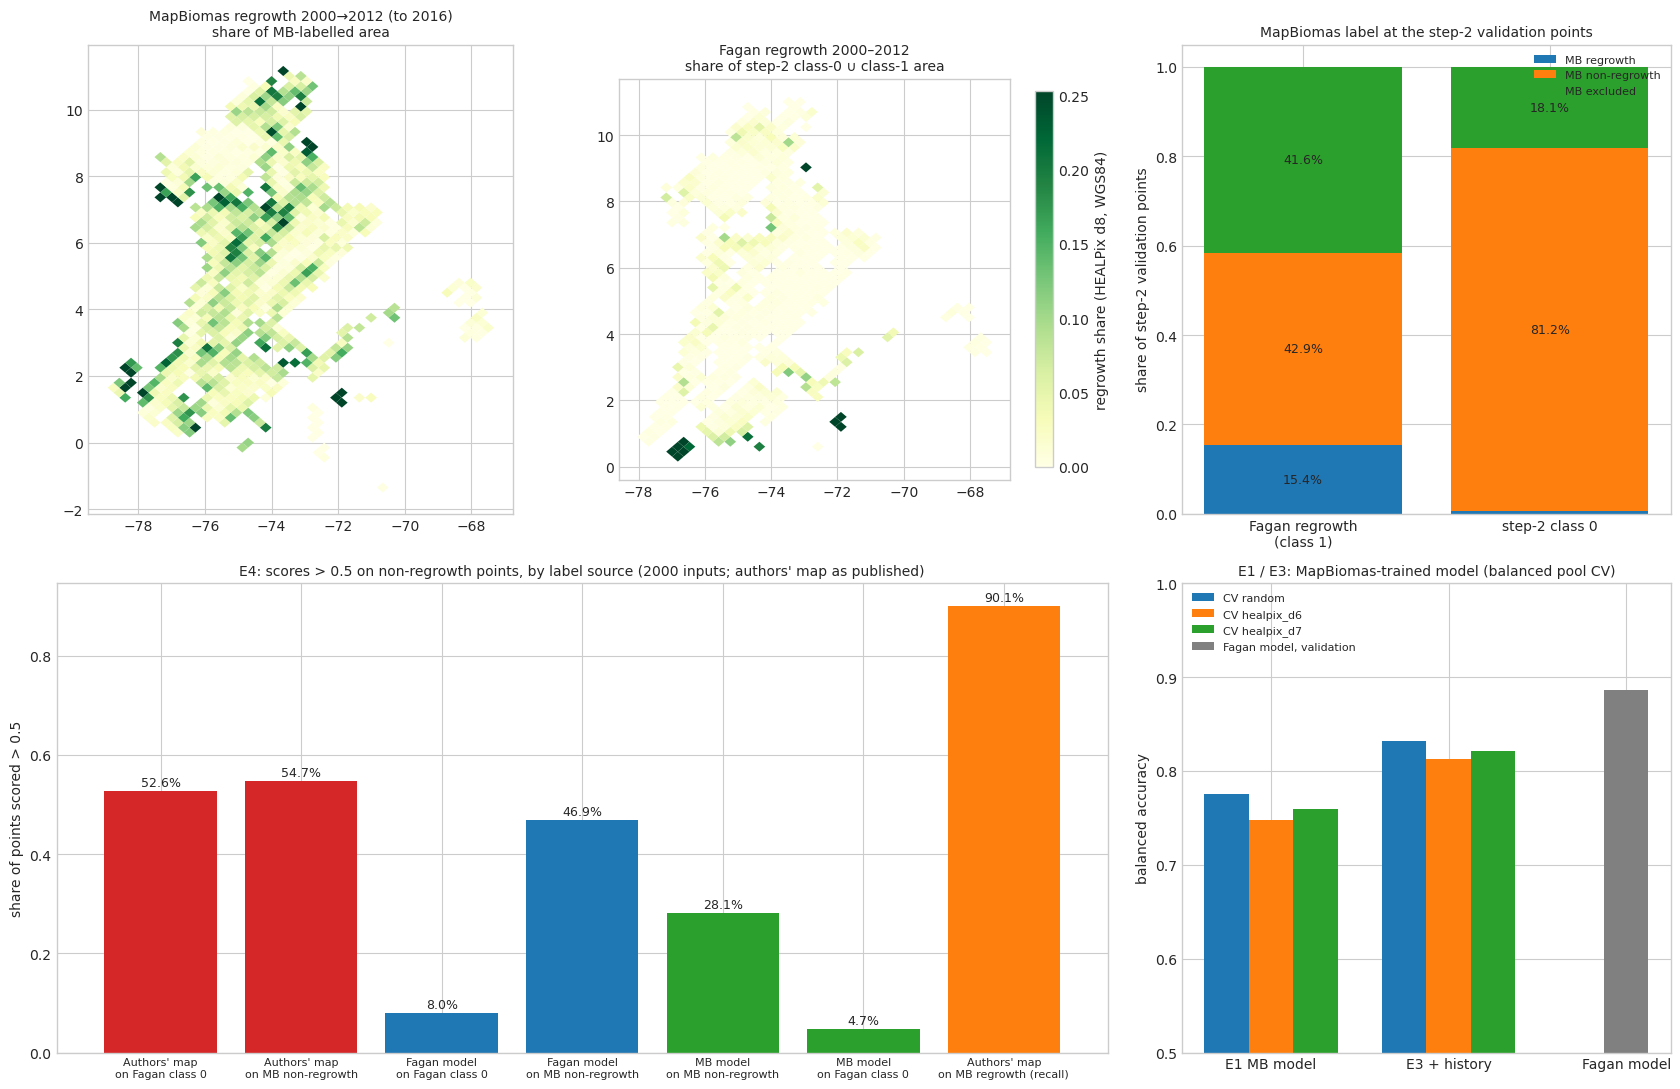

In [9]:
def cell_polys(ids: np.ndarray) -> list[np.ndarray]:
    lo, la = vertices(ids.astype("uint64"), HP_DEPTH, ellipsoid="WGS84")
    lo = (np.asarray(lo) + 180) % 360 - 180
    return [np.column_stack([a, b]) for a, b in zip(lo, np.asarray(la))]


def cell_share(mask_num: np.ndarray, mask_den: np.ndarray) -> pd.Series:
    df = pd.DataFrame({"cell": gcell, "num": grid.a * mask_num, "den": grid.a * mask_den}).groupby("cell").sum()
    return (df.num / df.den).where(df.den > 0.1 * df.den.max())


fig = plt.figure(figsize=(17, 11))
gs = fig.add_gridspec(2, 3)
maps = [(cell_share((grid[L] == 1).to_numpy(), (grid[L] >= 0).to_numpy()), "MapBiomas regrowth 2000→2012 (to 2016)\n"
         "share of MB-labelled area"),
        (cell_share((grid.label == 1).to_numpy(), (grid.label >= 0).to_numpy()), "Fagan regrowth 2000–2012\n"
         "share of step-2 class-0 ∪ class-1 area")]
vmax = float(np.nanquantile(np.r_[maps[0][0].dropna(), maps[1][0].dropna()], 0.98))
for i, (s, title) in enumerate(maps):
    ax = fig.add_subplot(gs[0, i])
    s = s.dropna()
    pc = PolyCollection(cell_polys(s.index.to_numpy()), array=s.to_numpy(), cmap="YlGn", edgecolor="none")
    pc.set_clim(0, vmax)
    ax.add_collection(pc)
    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
fig.colorbar(pc, ax=fig.axes[1], shrink=0.8, label="regrowth share (HEALPix d8, WGS84)")
ax = fig.add_subplot(gs[0, 2])
cats = [(1, "mb_regrowth", "MB regrowth"), (0, "mb_nonregrowth", "MB non-regrowth"), (-1, "mb_excluded", "MB excluded")]
bottom = np.zeros(2)
for _, key, lab in cats:
    vals = [e1_labels.set_index("metric").value[f"points_validation_{n}_share_{key}"] for n in ["fagan_regrowth", "fagan_class0"]]
    ax.bar([0, 1], vals, bottom=bottom, label=lab)
    for xx, (b, v) in enumerate(zip(bottom, vals)):
        if v > 0.02:
            ax.text(xx, b + v / 2, f"{v:.1%}", ha="center", va="center", fontsize=9)
    bottom += vals
ax.set_xticks([0, 1], ["Fagan regrowth\n(class 1)", "step-2 class 0"])
ax.set_ylabel("share of step-2 validation points")
ax.set_title("MapBiomas label at the step-2 validation points", fontsize=10)
ax.legend(fontsize=8)
ax = fig.add_subplot(gs[1, :2])
r4 = res.set_index(["experiment", "metric"]).value
bars = [("Authors' map\non Fagan class 0", r4.get(("E4_authors_map", "fagan_validation_nonregrowth_share_gt50"))),
        ("Authors' map\non MB non-regrowth", r4.get(("E4_authors_map", "mb_validation_nonregrowth_share_gt50"))),
        ("Fagan model\non Fagan class 0", r4.get(("E4_fagan_model_on_fagan_labels", "share_gt05_nonregrowth"))),
        ("Fagan model\non MB non-regrowth", r4.get(("E4_fagan_model_on_mapbiomas_labels", "share_gt05_nonregrowth"))),
        ("MB model\non MB non-regrowth", r4.get(("E4_mapbiomas_model_on_mapbiomas_labels", "share_gt05_nonregrowth"))),
        ("MB model\non Fagan class 0", r4.get(("E4_mapbiomas_model_on_fagan_labels", "share_gt05_nonregrowth"))),
        ("Authors' map\non MB regrowth (recall)", r4.get(("E4_authors_map", "mb_validation_regrowth_share_gt50")))]
ax.bar(range(len(bars)), [b[1] for b in bars], color=["C3", "C3", "C0", "C0", "C2", "C2", "C1"])
for i, b in enumerate(bars):
    ax.text(i, b[1] + 0.01, f"{b[1]:.1%}", ha="center", fontsize=9)
ax.set_xticks(range(len(bars)), [b[0] for b in bars], fontsize=8)
ax.set_ylabel("share of points scored > 0.5")
ax.set_title("E4: scores > 0.5 on non-regrowth points, by label source (2000 inputs; authors' map as published)",
             fontsize=10)
ax = fig.add_subplot(gs[1, 2])
r1 = res.set_index(["experiment", "metric"]).value
labels_ = ["E1 MB model", "E3 + history", "Fagan model"]
for j, sch in enumerate(["random", "healpix_d6", "healpix_d7"]):
    vals = [r1.get(("E1_mapbiomas_model", f"cv_{sch}_balanced_accuracy")),
            r1.get(("E3_mapbiomas_model_with_history", f"cv_{sch}_balanced_accuracy")), np.nan]
    ax.bar(np.arange(3) + (j - 1) * 0.25, vals, 0.25, label=f"CV {sch}")
ax.bar(2, r1.get(("E4_fagan_model_on_fagan_labels", "balanced_accuracy")), 0.25, color="0.5", label="Fagan model, validation")
ax.set_xticks(range(3), labels_)
ax.set_ylim(0.5, 1)
ax.set_ylabel("balanced accuracy")
ax.set_title("E1 / E3: MapBiomas-trained model (balanced pool CV)", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "mapbiomas_labels.png", dpi=150, bbox_inches="tight")
plt.show()

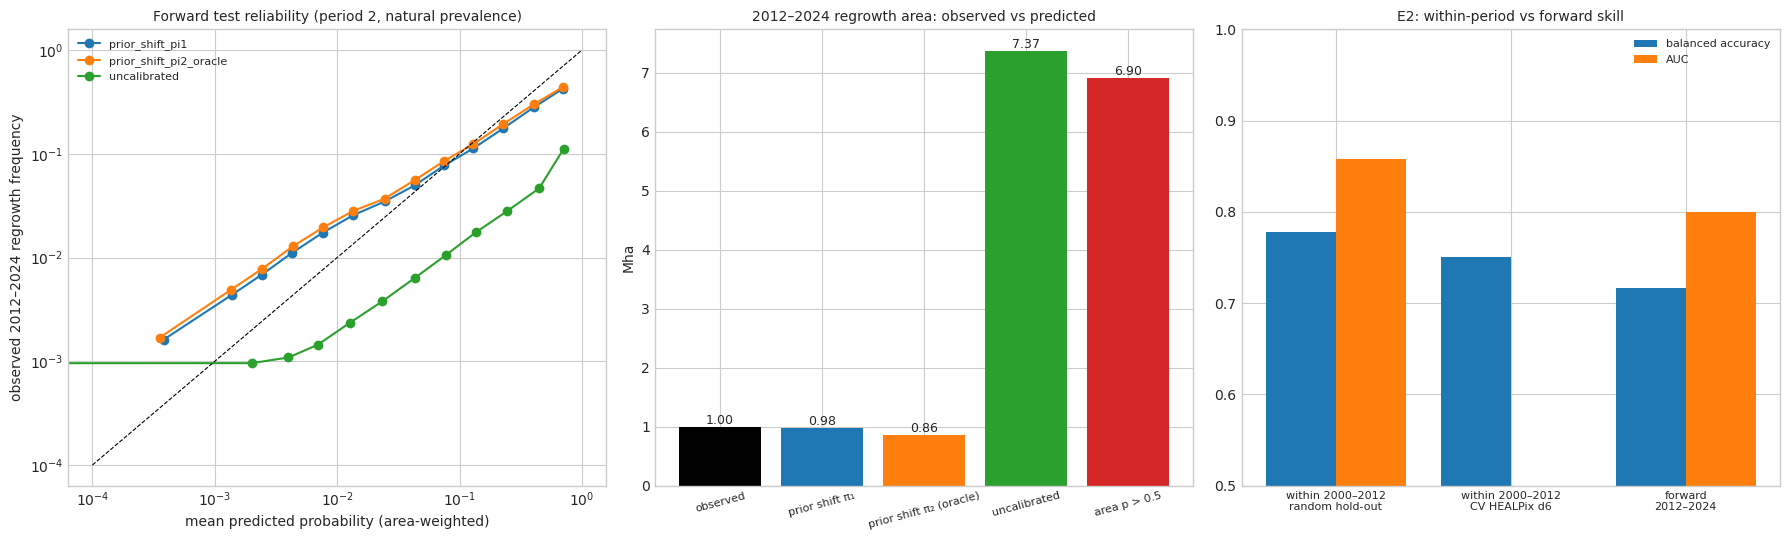

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
ax = axes[0]
for nm, gr in rel.groupby("score"):
    ax.plot(gr.mean_pred, gr.obs_freq, "o-", label=nm)
ax.plot([1e-4, 1], [1e-4, 1], "k--", lw=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("mean predicted probability (area-weighted)")
ax.set_ylabel("observed 2012–2024 regrowth frequency")
ax.set_title("Forward test reliability (period 2, natural prevalence)", fontsize=10)
ax.legend(fontsize=8)
ax = axes[1]
e2i = e2.set_index(["scope", "metric"]).value
items = [("observed", e2i[("period2_forward_all", "observed_regrowth_area_mha")]),
         ("prior shift π₁", e2i[("period2_forward_all", "predicted_regrowth_area_prior_shift_pi1_mha")]),
         ("prior shift π₂ (oracle)", e2i[("period2_forward_all", "predicted_regrowth_area_prior_shift_pi2_oracle_mha")]),
         ("uncalibrated", e2i[("period2_forward_all", "predicted_regrowth_area_uncalibrated_mha")]),
         ("area p > 0.5", e2i[("period2_forward_all", "area_p_gt05_uncalibrated_mha")])]
ax.bar(range(len(items)), [v for _, v in items], color=["k", "C0", "C1", "C2", "C3"])
for i, (_, v) in enumerate(items):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(items)), [k for k, _ in items], fontsize=8, rotation=15)
ax.set_ylabel("Mha")
ax.set_title("2012–2024 regrowth area: observed vs predicted", fontsize=10)
ax = axes[2]
rows_ = [("within 2000–2012\nrandom hold-out", "period1_random_holdout", "balanced_accuracy", "auc"),
         ("within 2000–2012\nCV HEALPix d6", "period1_cv", "cv_healpix_d6_balanced_accuracy", None),
         ("forward\n2012–2024", "period2_forward_all", "balanced_accuracy", "auc")]
for i, (lab, sc, m_ba, m_auc) in enumerate(rows_):
    ax.bar(i - 0.2, e2i[(sc, m_ba)], 0.4, color="C0", label="balanced accuracy" if i == 0 else None)
    if m_auc:
        ax.bar(i + 0.2, e2i[(sc, m_auc)], 0.4, color="C1", label="AUC" if i == 0 else None)
ax.set_xticks(range(len(rows_)), [r[0] for r in rows_], fontsize=8)
ax.set_ylim(0.5, 1)
ax.legend(fontsize=8)
ax.set_title("E2: within-period vs forward skill", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "mapbiomas_forward_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
json.dump({"pi_mapbiomas_e1": PI_MB, "pi_fagan": PI_FAGAN, "pi1": PI1, "pi2": PI2, "n_train": N_TRAIN, "n_trees": N_TREES},
          open(RESULTS / "mapbiomas_meta.json", "w"), indent=2)